# Time series benchmarking tutorial (Hydrology CAMELS US with Chronos 2)

This is the **main DS5110 final notebook**.

## Stage 1: Data input and preprocessing

- Input file: `data/raw/BasicInputTimeSeries_us.csv`
- Task: single-step forecasting setup preparation
- Input mode: strictly univariate (`QObs(mm/d)` only)
- Lookback window: 30
- Split: location holdout by `basin_id` (80% train locations, 20% test locations)

In this stage, we focus on loading, validating, cleaning, splitting, and saving processed artifacts for Chronos-2 evaluation.


In [20]:
!git clone https://github.com/JunyangHe/timeseries_benchmark_tutorial.git

Cloning into 'timeseries_benchmark_tutorial'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 70 (delta 12), reused 14 (delta 7), pack-reused 43 (from 3)
Receiving objects: 100% (70/70), 89.14 MiB | 16.44 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [21]:
%cd timeseries_benchmark_tutorial
!pip install -q -r requirements.txt

/content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial


In [22]:
!git pull

Already up to date.


In [23]:
!unzip "./data/raw/BasicInputTimeSeries_us.zip"

Archive:  ./data/raw/BasicInputTimeSeries_us.zip
  inflating: BasicInputTimeSeries_us.csv  


In [24]:
# Install dependencies (Colab-friendly, configurable)
import os
import subprocess
import sys
from pathlib import Path


def find_in_cwd_or_parents(filename: str, start: Path, max_levels: int = 6):
    cur = start.resolve()
    for _ in range(max_levels + 1):
        candidate = cur / filename
        if candidate.exists():
            return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    return None


req_override = os.getenv('REQUIREMENTS_PATH', '').strip()
req_path = Path(req_override).expanduser() if req_override else find_in_cwd_or_parents('requirements.txt', Path.cwd())

if req_path is not None and req_path.exists():
    print(f'Installing from: {req_path.resolve()}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(req_path)])
else:
    print('requirements.txt not found. Installing fallback packages...')
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'pandas>=2.0',
        'numpy>=1.24',
        'matplotlib>=3.7',
        'pyarrow>=14.0',
        'chronos-forecasting>=2.0',
        'torch>=2.1',
        'tqdm>=4.66',
        'pyyaml>=6.0',
    ])

print('Dependency installation complete.')

Installing from: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/requirements.txt
Dependency installation complete.


In [25]:
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Optional Colab Drive mount:
# from google.colab import drive
# drive.mount('/content/drive')


def find_project_root(start: Path, max_levels: int = 8) -> Path:
    """Pick nearest parent that looks like this repo."""
    cur = start.resolve()
    for _ in range(max_levels + 1):
        if (cur / 'src').exists() and (cur / 'notebooks').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()


def resolve_input_csv(project_root: Path, relative_default: Path) -> Path:
    """
    Resolve input CSV by priority:
    1) INPUT_CSV_PATH env var
    2) <project_root>/<relative_default>
    3) <cwd>/<relative_default>
    4) first recursive match by filename under project_root, then cwd
    """
    env_path = os.getenv('INPUT_CSV_PATH', '').strip()
    if env_path:
        return Path(env_path).expanduser()

    candidate = project_root / relative_default
    if candidate.exists():
        return candidate

    candidate = Path.cwd() / relative_default
    if candidate.exists():
        return candidate

    filename = relative_default.name
    match = next(project_root.rglob(filename), None)
    if match is not None:
        return match

    match = next(Path.cwd().rglob(filename), None)
    if match is not None:
        return match

    return project_root / relative_default


# ----------------------------
# User-editable runtime config
# ----------------------------
DATA_RELATIVE_PATH = Path('./data/raw/BasicInputTimeSeries_us.csv')
MODEL_ID = os.getenv('CHRONOS_MODEL_ID', 'amazon/chronos-2')
LOOKBACK_WINDOW = 30
FORECAST_HORIZON = 1

# Location-based split config: 80% train basins, 20% test basins
TRAIN_LOCATION_RATIO = 0.8
TEST_LOCATION_RATIO = 0.2
SPLIT_RANDOM_SEED = 42

TIMESTAMP_COL = 'Year_Mnth_Day'
ID_COL = 'basin_id'
TARGET_COL = 'QObs(mm/d)'
REQUIRED_COLUMNS = [TIMESTAMP_COL, ID_COL, TARGET_COL]

PROJECT_ROOT = find_project_root(Path.cwd())
INPUT_CSV_PATH = resolve_input_csv(PROJECT_ROOT, DATA_RELATIVE_PATH)
OUTPUT_ROOT = PROJECT_ROOT

OUTPUT_DIRS = [
    OUTPUT_ROOT / 'metadata',
    OUTPUT_ROOT / 'results',
    OUTPUT_ROOT / 'results' / 'figures',
    OUTPUT_ROOT / 'data' / 'processed',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Resolved input path:', INPUT_CSV_PATH)
print('Output root:', OUTPUT_ROOT.resolve())
print('Model ID:', MODEL_ID)

Project root: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial
Resolved input path: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/BasicInputTimeSeries_us.csv
Output root: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial
Model ID: amazon/chronos-2


In [26]:
import sys

# Make src/ imports work in both local and Colab contexts without fixed absolute paths.
src_candidates = [
    PROJECT_ROOT / 'src',
    Path.cwd() / 'src',
    Path.cwd().parent / 'src',
]

src_path = next((p for p in src_candidates if p.exists()), None)
if src_path is None:
    raise FileNotFoundError('Could not find src/ directory. Ensure notebook runs inside the repository.')

sys.path.insert(0, str(src_path.resolve()))
print('Using src path:', src_path.resolve())

from chronos import Chronos2Pipeline
from data_utils import (
    DataSpec,
    build_context_and_test,
    load_and_prepare_csv,
    location_holdout_split,
    to_chronos_df,
)
from eval_utils import rolling_one_step_predictions
from metrics import rmse
from plotting_utils import plot_actual_vs_predicted

Using src path: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/src


In [27]:
# Load quick preview and validate required columns
if not INPUT_CSV_PATH.exists():
    raise FileNotFoundError(
        'Input CSV not found. Set env var INPUT_CSV_PATH or place file at data/raw/BasicInputTimeSeries_us.csv'
    )

preview_df = pd.read_csv(INPUT_CSV_PATH, nrows=5)
print('Preview columns:', list(preview_df.columns))
print(preview_df.head())

missing_required = [c for c in REQUIRED_COLUMNS if c not in preview_df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

print('Required columns found:', REQUIRED_COLUMNS)

Preview columns: ['Unnamed: 0', 'Year_Mnth_Day', 'basin_id', 'PRCP(mm/day)', 'Tmean(C)', 'QObs(mm/d)']
   Unnamed: 0 Year_Mnth_Day  basin_id  PRCP(mm/day)  Tmean(C)  QObs(mm/d)
0           0    1989-10-02   1013500         10.38      8.71    0.321506
1           1    1989-10-02   1022500         12.31     10.22    0.553697
2           2    1989-10-02   1030500          3.21      9.58    0.679783
3           3    1989-10-02   1031500          2.57     10.38    0.567653
4           4    1989-10-02   1047000          5.77      8.59    0.720152
Required columns found: ['Year_Mnth_Day', 'basin_id', 'QObs(mm/d)']


In [28]:
# Load full dataset and preprocess
spec = DataSpec(
    timestamp_col=TIMESTAMP_COL,
    id_col=ID_COL,
    target_col=TARGET_COL,
    drop_unnamed_first_col=True,  # user requirement
)

raw_df = load_and_prepare_csv(INPUT_CSV_PATH, spec)

print('Prepared rows:', len(raw_df))
print('Prepared basins:', raw_df[ID_COL].nunique())
print('Date range:', raw_df[TIMESTAMP_COL].min(), 'to', raw_df[TIMESTAMP_COL].max())
print(raw_df[[TIMESTAMP_COL, ID_COL, TARGET_COL]].head())

Prepared rows: 4717801
Prepared basins: 671
Date range: 1989-10-02 00:00:00 to 2008-12-31 00:00:00
  Year_Mnth_Day  basin_id  QObs(mm/d)
0    1989-10-02   1013500    0.321506
1    1989-10-03   1013500    0.338826
2    1989-10-04   1013500    0.320423
3    1989-10-05   1013500    0.309598
4    1989-10-06   1013500    0.305268


In [29]:
# Location-based split: random 80% train basins, 20% test basins
splits = location_holdout_split(
    raw_df,
    id_col=ID_COL,
    train_location_ratio=TRAIN_LOCATION_RATIO,
    random_seed=SPLIT_RANDOM_SEED,
)

train_df_raw = splits['train']
val_df_raw = splits['val']  # empty by design for this split strategy
test_df_raw = splits['test']

train_locs = set(train_df_raw[ID_COL].dropna().unique().tolist())
test_locs = set(test_df_raw[ID_COL].dropna().unique().tolist())

print('Train rows:', len(train_df_raw))
print('Test rows:', len(test_df_raw))
print('Train locations:', len(train_locs))
print('Test locations:', len(test_locs))
print('Location overlap count:', len(train_locs.intersection(test_locs)))

# Convert to Chronos long format
train_df = to_chronos_df(train_df_raw, id_col=ID_COL, timestamp_col=TIMESTAMP_COL, target_col=TARGET_COL)
val_df = to_chronos_df(val_df_raw, id_col=ID_COL, timestamp_col=TIMESTAMP_COL, target_col=TARGET_COL)
test_df = to_chronos_df(test_df_raw, id_col=ID_COL, timestamp_col=TIMESTAMP_COL, target_col=TARGET_COL)

print('\nChronos-formatted train sample:')
print(train_df.head())
print('\nChronos-formatted test sample:')
print(test_df.head())

Train rows: 3775647
Test rows: 942154
Train locations: 537
Test locations: 134
Location overlap count: 0

Chronos-formatted train sample:
         id  timestamp    target
0  10023000 1989-10-02  0.120834
1  10023000 1989-10-03  0.117227
2  10023000 1989-10-04  0.115424
3  10023000 1989-10-05  0.117227
4  10023000 1989-10-06  0.117227

Chronos-formatted test sample:
         id  timestamp    target
0  10172700 1989-10-02  0.083163
1  10172700 1989-10-03  0.086943
2  10172700 1989-10-04  0.086943
3  10172700 1989-10-05  0.090723
4  10172700 1989-10-06  0.086943


In [30]:
# Save processed artifacts for reproducible next stages
processed_dir = OUTPUT_ROOT / 'data' / 'processed'

train_df.to_parquet(processed_dir / 'train_chronos.parquet', index=False)
val_df.to_parquet(processed_dir / 'val_chronos.parquet', index=False)
test_df.to_parquet(processed_dir / 'test_chronos.parquet', index=False)

# Small CSV heads for quick inspection
train_df.head(1000).to_csv(processed_dir / 'train_preview_1000.csv', index=False)
val_df.head(1000).to_csv(processed_dir / 'val_preview_1000.csv', index=False)
test_df.head(1000).to_csv(processed_dir / 'test_preview_1000.csv', index=False)

print('Saved processed splits to:', processed_dir.resolve())

Saved processed splits to: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/data/processed


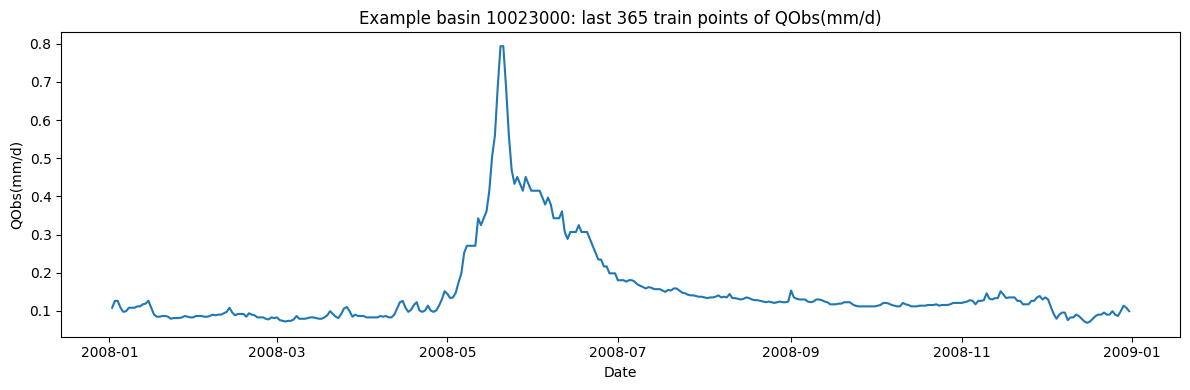

Saved: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/results/figures/preprocess_example_series.png


In [31]:
# Quick data sanity visualization (preprocessing stage)
# Plot target over time for one example basin.
example_id = str(train_df['id'].iloc[0])
example_series = train_df[train_df['id'] == example_id].sort_values('timestamp').tail(365)

plt.figure(figsize=(12, 4))
plt.plot(example_series['timestamp'], example_series['target'])
plt.title(f'Example basin {example_id}: last 365 train points of {TARGET_COL}')
plt.xlabel('Date')
plt.ylabel(TARGET_COL)
plt.tight_layout()

prep_fig_path = OUTPUT_ROOT / 'results' / 'figures' / 'preprocess_example_series.png'
plt.savefig(prep_fig_path, dpi=150)
plt.show()
print('Saved:', prep_fig_path)

In [32]:
# Save preprocessing summary for reproducibility
preprocess_summary = {
    'project_root': str(PROJECT_ROOT),
    'input_csv_path': str(INPUT_CSV_PATH),
    'timestamp_column': TIMESTAMP_COL,
    'id_column': ID_COL,
    'target_column': TARGET_COL,
    'drop_unnamed_first_column': True,
    'fill_strategy': 'forward_fill_within_basin',
    'split_strategy': 'location_holdout_random',
    'train_location_ratio': TRAIN_LOCATION_RATIO,
    'test_location_ratio': TEST_LOCATION_RATIO,
    'split_random_seed': SPLIT_RANDOM_SEED,
    'lookback_window': LOOKBACK_WINDOW,
    'forecast_horizon': FORECAST_HORIZON,
    'prepared_rows': int(len(raw_df)),
    'prepared_basins': int(raw_df[ID_COL].nunique()),
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'train_locations': int(len(train_locs)),
    'test_locations': int(len(test_locs)),
}

summary_path = OUTPUT_ROOT / 'results' / 'preprocessing_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(preprocess_summary, f, indent=2)

print('Saved:', summary_path)
print(json.dumps(preprocess_summary, indent=2))

Saved: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/results/preprocessing_summary.json
{
  "project_root": "/content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial",
  "input_csv_path": "/content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/BasicInputTimeSeries_us.csv",
  "timestamp_column": "Year_Mnth_Day",
  "id_column": "basin_id",
  "target_column": "QObs(mm/d)",
  "drop_unnamed_first_column": true,
  "fill_strategy": "forward_fill_within_basin",
  "split_strategy": "location_holdout_random",
  "train_location_ratio": 0.8,
  "test_location_ratio": 0.2,
  "split_random_seed": 42,
  "lookback_window": 30,
  "forecast_horizon": 1,
  "prepared_rows": 4717801,
  "prepared_basins": 671,
  "train_rows": 3775647,
  "val_rows": 0,
  "test_rows": 942154,
  "train_locations": 537,
  "test_locations": 134
}


Using device: cuda
Context rows: 3775647 | Test rows: 942154


Rolling inference:   0%|          | 0/134 [00:00<?, ?it/s]

Rolling inference debug samples:
{'id': '10172700', 'step_idx': 0, 'history_last_timestamp': Timestamp('1989-10-31 00:00:00'), 'actual_timestamp': Timestamp('1989-11-01 00:00:00'), 'pred_timestamp': Timestamp('1989-11-01 00:00:00'), 'prediction_column': '0.5', 'pred_df_columns': ['id', 'timestamp', 'target_name', 'predictions', '0.5'], 'predicted_value': 0.08843906223773956, 'actual_value': 0.0869429495563873}
{'id': '10172700', 'step_idx': 1, 'history_last_timestamp': Timestamp('1989-11-01 00:00:00'), 'actual_timestamp': Timestamp('1989-11-02 00:00:00'), 'pred_timestamp': Timestamp('1989-11-02 00:00:00'), 'prediction_column': '0.5', 'pred_df_columns': ['id', 'timestamp', 'target_name', 'predictions', '0.5'], 'predicted_value': 0.08792409300804138, 'actual_value': 0.0869429495563873}
{'id': '10172700', 'step_idx': 2, 'history_last_timestamp': Timestamp('1989-11-02 00:00:00'), 'actual_timestamp': Timestamp('1989-11-03 00:00:00'), 'pred_timestamp': Timestamp('1989-11-03 00:00:00'), 'pred

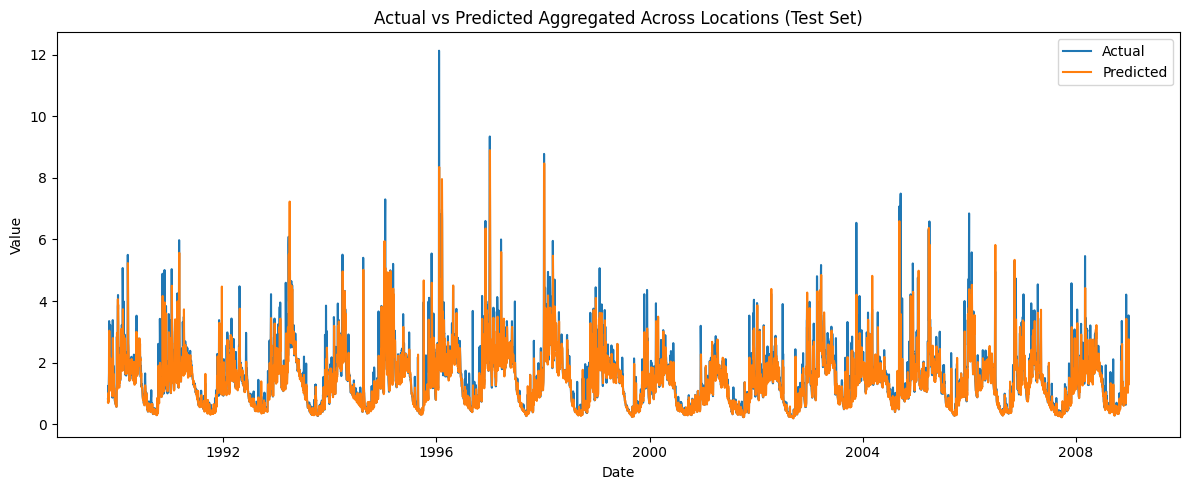

Saved: /content/timeseries_benchmark_tutorial/timeseries_benchmark_tutorial/results/benchmark_results.json
{
  "dataset_name": "CAMELS-US",
  "model_name": "chronos-2",
  "target_variable": "QObs(mm/d)",
  "lookback_window": 30,
  "forecast_horizon": 1,
  "model_parameters": {
    "model_id": "amazon/chronos-2",
    "prediction_length": 1,
    "quantile_levels": [
      0.5
    ],
    "device_map": "cuda"
  },
  "rmse": 2.451361768118934,
  "notes": "Overall RMSE on location-holdout test split (20% randomly selected basin IDs)."
}


In [33]:
# Stage 2: Chronos-2 inference, RMSE, and Actual vs Predicted
import torch

device_map = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device_map)

context_df, eval_test_df = build_context_and_test(train_df, val_df, test_df)
print('Context rows:', len(context_df), '| Test rows:', len(eval_test_df))

pipeline = Chronos2Pipeline.from_pretrained(MODEL_ID, device_map=device_map)

pred_test_df = rolling_one_step_predictions(
    pipeline=pipeline,
    context_df=context_df,
    test_df=eval_test_df,
    lookback_window=LOOKBACK_WINDOW,
    quantile_levels=[0.5],
    debug_first_n=5,
    allow_test_cold_start=True,
)

if pred_test_df.empty:
    raise RuntimeError(
        'Prediction output is empty. For location-holdout, ensure each test basin has > lookback_window points.'
    )

# Debug checks to verify Chronos input/output alignment
print('\nPrediction dataframe columns:', pred_test_df.columns.tolist())
print('Unique IDs in predictions:', pred_test_df['id'].nunique())
if 'prediction_column' in pred_test_df.columns:
    print('Prediction columns used:', pred_test_df['prediction_column'].value_counts(dropna=False).head())
if 'timestamp_aligned' in pred_test_df.columns:
    align_rate = float(pred_test_df['timestamp_aligned'].mean())
    print(f'Timestamp alignment rate: {align_rate:.4f}')

# If timestamps are not perfectly aligned, evaluate only aligned rows.
rmse_eval_df = pred_test_df
if 'timestamp_aligned' in pred_test_df.columns and pred_test_df['timestamp_aligned'].notna().any():
    aligned_df = pred_test_df[pred_test_df['timestamp_aligned']].copy()
    if len(aligned_df) > 0:
        rmse_eval_df = aligned_df
        print('Using aligned rows for RMSE:', len(rmse_eval_df))

overall_test_rmse = rmse(rmse_eval_df['actual'].values, rmse_eval_df['predicted'].values)
print('Overall test RMSE:', overall_test_rmse)

pred_path = OUTPUT_ROOT / 'results' / 'predictions_test.csv'
pred_test_df.to_csv(pred_path, index=False)
print('Saved:', pred_path)

fig_path = OUTPUT_ROOT / 'results' / 'figures' / 'actual_vs_predicted.png'
plot_actual_vs_predicted(pred_test_df, str(fig_path))
print('Saved:', fig_path)

# Aggregate actual/predicted across all locations for each date, then plot as time series
plot_df = pred_test_df.copy()
plot_df['timestamp'] = pd.to_datetime(plot_df['timestamp'])

daily_df = (
    plot_df.groupby('timestamp', as_index=False)[['actual', 'predicted']]
    .mean()
    .sort_values('timestamp')
)

plt.figure(figsize=(12, 5))
plt.plot(daily_df['timestamp'], daily_df['actual'], label='Actual')
plt.plot(daily_df['timestamp'], daily_df['predicted'], label='Predicted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Actual vs Predicted Aggregated Across Locations (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

benchmark_result = {
    'dataset_name': 'CAMELS-US',
    'model_name': 'chronos-2',
    'target_variable': TARGET_COL,
    'lookback_window': LOOKBACK_WINDOW,
    'forecast_horizon': FORECAST_HORIZON,
    'model_parameters': {
        'model_id': MODEL_ID,
        'prediction_length': 1,
        'quantile_levels': [0.5],
        'device_map': device_map,
        'split_strategy': 'location_holdout_random',
        'train_location_ratio': TRAIN_LOCATION_RATIO,
        'test_location_ratio': TEST_LOCATION_RATIO,
        'split_random_seed': SPLIT_RANDOM_SEED,
        'allow_test_cold_start': True,
        'debug_first_n': 5,
    },
    'rmse': float(overall_test_rmse),
    'notes': 'Overall RMSE on location-holdout test split (20% randomly selected basin IDs).',
}

benchmark_path = OUTPUT_ROOT / 'results' / 'benchmark_results.json'
with open(benchmark_path, 'w', encoding='utf-8') as f:
    json.dump(benchmark_result, f, indent=2)

print('Saved:', benchmark_path)
print(json.dumps(benchmark_result, indent=2))

In [34]:
# Update required experiment metadata with run parameters
experiment_cfg_path = OUTPUT_ROOT / 'metadata' / 'experiment_config.json'

if experiment_cfg_path.exists():
    with open(experiment_cfg_path, 'r', encoding='utf-8') as f:
        exp_cfg = json.load(f)

    exp_cfg['lookback_window'] = int(LOOKBACK_WINDOW)
    exp_cfg['forecast_horizon'] = int(FORECAST_HORIZON)
    exp_cfg['evaluation_metric'] = 'rmse'
    exp_cfg['execution_environment'] = 'google_colab'
    exp_cfg['model_parameters'] = {
        'prediction_length': 1,
        'quantile_levels': [0.5],
        'device_preference': 'cuda_if_available_else_cpu',
        'split_strategy': 'location_holdout_random',
        'train_location_ratio': TRAIN_LOCATION_RATIO,
        'test_location_ratio': TEST_LOCATION_RATIO,
        'split_random_seed': SPLIT_RANDOM_SEED,
        'allow_test_cold_start': True,
        'debug_first_n': 5,
    }

    with open(experiment_cfg_path, 'w', encoding='utf-8') as f:
        json.dump(exp_cfg, f, indent=2)

print('Experiment metadata refresh complete.')

Metadata refresh complete.


## Outputs after full run

- `data/processed/train_chronos.parquet`
- `data/processed/val_chronos.parquet`
- `data/processed/test_chronos.parquet`
- `data/processed/*_preview_1000.csv`
- `results/preprocessing_summary.json`
- `results/predictions_test.csv`
- `results/benchmark_results.json`
- `results/figures/preprocess_example_series.png`
- `results/figures/actual_vs_predicted.png`
- updated `metadata/experiment_config.json`

## Optional Colab overrides

Use environment variables if your files are in custom locations:

```python
import os
os.environ['INPUT_CSV_PATH'] = '/content/BasicInputTimeSeries_us.csv'
os.environ['REQUIREMENTS_PATH'] = '/content/requirements.txt'
os.environ['CHRONOS_MODEL_ID'] = 'amazon/chronos-2'
```